# Explore NOAA NODD CDR SST
* use Virtualizarr to create a cloud-optimized virtual dataset from multiple remote NetCDF files
* explore the virtual dataset using Holoviz tools
* compute in parallel using Dask

In [1]:

import fsspec

In [2]:
fs = fsspec.filesystem("s3", anon=True)  # lets you explore the s3 like it's a file system 

In [6]:
fs.ls('s3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/') # makes s3 look like a file system. also does that for google drive, ftp sites, other stuff 

['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2',
 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1']

In [7]:
oisst_files = fs.glob(  # glob allows you to do wildcarding 
    "s3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.*.nc"  # pick up all files from month of march 
)

oisst_files = sorted(["s3://" + f for f in oisst_files])  # sort results and add s3://

In [8]:
oisst_files

['s3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250301.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250302.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250303.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250304.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250305.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250306_preliminary.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250307_preliminary.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202503/oisst-avhrr-v02r01.20250308_preliminary.nc',
 's3://noaa-cdr-sea-surface-temp-optimum-int

In [9]:
# looks like there are five files for month of march, and we need to concatenate them, so I can easily take a time series through it etc. 

In [11]:
# take a look at one of them to see what they look like
import xarray as xr

In [12]:
ds = xr.open_dataset(fs.open(oisst_files[0]))

In [13]:
ds

<xarray.Dataset> Size: 17MB
Dimensions:  (time: 1, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-03-01T12:00:00
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, zlev, lat, lon) float32 4MB ...
    anom     (time, zlev, lat, lon) float32 4MB ...
    err      (time, zlev, lat, lon) float32 4MB ...
    ice      (time, zlev, lat, lon) float32 4MB ...
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    id:                         oisst-avhrr-v02r01.20250301.nc
    naming_authority:           gov.noaa.ncei
    ...                         ...
    time_coverage_start:        2025-03-01T00:00:00Z
    time_coverage_end:          2025-03-01T23:59:59Z
    metadata_link:              https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    sensor:                     Thermometer, AVHRR

In [14]:
# a way to interactively look at one of the nc files
import hvplot.xarray

In [15]:
ds['sst']

<xarray.DataArray 'sst' (time: 1, zlev: 1, lat: 720, lon: 1440)> Size: 4MB
[1036800 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-03-01T12:00:00
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_min:  -300
    valid_max:  4500

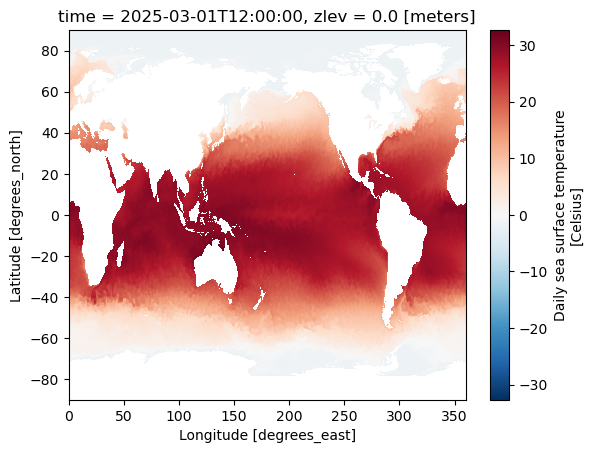

In [16]:
ds['sst'][0,0,:,:].plot() # take a look with matplotlib first

In [28]:
# you can see above that longitude is 0 to 360. Holoviz likes -180 to 180...
ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon')

In [29]:
ds['sst'][0,0,:,:].hvplot.quadmesh(x='lon', y='lat', geo=True, rasterize=True, tiles='OSM', frame_width=600) # last option is helpful to render in the backend and then deliver when done. makes it plot much faster. 
# geo = True makes it know it's lat long and then it's less stretched out. tiles shows basemap. 

# ds['sst'][0,0,:,:].hvplot.quadmesh(x='lon', y='lat', geo=True, rasterize=True, frame_width=600) 

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [lon,lat]   (Daily sea surface temperature)

In [10]:
print(len(oisst_files))

19


In [23]:
from virtualizarr import open_virtual_dataset # replaces kerchunk for creating references for netcdf parallel loading 

In [24]:
so = dict(anon=True) # need to tell VZ what kind of access it needs for this dataset. this is public. dict is a way to turn a bunch o things into dictionary items. 

In [25]:
%%time
virtual_datasets = [
    open_virtual_dataset(url, indexes={}, reader_options={"storage_options": so}, )
    for url in oisst_files
] # will run thru 18 urls 

CPU times: user 727 ms, sys: 41.3 ms, total: 768 ms
Wall time: 4.62 s


In [26]:
import xarray as xr

In [27]:
# this Dataset wraps a bunch of virtual ManifestArray objects directly. Now can use xarray concat to aggregate along time dim 
virtual_ds = xr.concat(
    virtual_datasets,
    dim="time",
    coords="minimal",
    compat="override",
    combine_attrs="override",
)
# cache the combined dataset pattern to disk, in this case using the existing kerchunk specification for reference files
virtual_ds.virtualize.to_kerchunk('combined.json', format='json')  
   # creates a combined.json file in your directory. Looks like a zarr dataset, but they are just references. 
   # the `to_kerchunk` stores it in the format kerchunk does/did. There is also icechunk which is newer, which will "soon be the latest and greatest". 
   # Don't use icechunk right now, it's still a mess, wait a few months. 

In [30]:
ds = xr.open_dataset('combined.json', engine='kerchunk', backend_kwargs={'storage_options':dict(remote_options=so)}, chunks={})  # normal xarray.Dataset object, wrapping dask/numpy arrays etc.
# uses the zarr library undre the hood, using the kerchunk engine. Each engine in xarray has it's own backend options. This information about options is specific to the cloud storage you're accessing.
# here it's for AWS but would/copuld be different for GCS or other... 

In [31]:
ds

<xarray.Dataset> Size: 630MB
Dimensions:  (time: 19, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time     (time) datetime64[ns] 152B 2025-03-01T12:00:00 ... 2025-03-19T12...
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float64 158MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float64 158MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float64 158MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float64 158MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    creator_email:              oisst-help@noaa.gov
    creator_url:                https://www.ncei.noaa.gov/
    date_created:               2025-03-16T13:43:00Z
    ...                         ...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    standard_name_vocabulary:   CF Standard Name Table (v40, 25 January 2017)
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    time_coverage_end:          2025-03-01T23:59:59Z
    time_coverage_start:        2025-03-01T00:00:00Z
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...

In [ ]:
# 19 "time steps", now using zarr library, which makes reading much more efficient. 

In [ ]:
import hvplot.xarray

In [ ]:
ds['sst'].nbytes/1e9

In [ ]:
ds['sst']

In [ ]:
ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))  #.sortby('lon')

In [47]:
%%time
da = ds['sst'][:5,0,:,:].load() # just doing and timing the load portion for comparison with before. Pulling 5 files now instead of 1. 

CPU times: user 125 ms, sys: 16.1 ms, total: 141 ms
Wall time: 696 ms


In [39]:
da

<xarray.DataArray 'sst' (time: 5, lat: 720, lon: 1440)> Size: 41MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-1.71999996, -1.73999996, -1.74999996, ..., -1.74999996,
         -1.73999996, -1.72999996],
        [-1.73999996, -1.75999996, -1.77999996, ..., -1.77999996,
         -1.76999996, -1.73999996],
        [-1.79999996, -1.79999996, -1.79999996, ..., -1.79999996,
         -1.79999996, -1.79999996]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [-1.71999996, -1.73999996, -1.73999996, ..., -1.74999996,
         -1.73999996, -1.72999996],
        [-1.73999996, -1.75999996, -1.77999996, ..., -1.77999996,
         -1.76999996, -1.73999996],
        [-1.79999996, -1.79999996, -1.79999996, ..., -1.79999996,
         -1.79999996, -1.79999996]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-1.71999996, -1.72999996, -1.73999996, ..., -1.74999996,
         -1.73999996, -1.72999996],
        [-1.72999996, -1.75999996, -1.77999996, ..., -1.77999996,
         -1.76999996, -1.73999996],
        [-1.79999996, -1.79999996, -1.79999996, ..., -1.79999996,
         -1.79999996, -1.79999996]]])
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time     (time) datetime64[ns] 40B 2025-03-01T12:00:00 ... 2025-03-05T12:...
    zlev     float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_max:  4500
    valid_min:  -300

In [45]:
da[0,:,:].hvplot.quadmesh(x='lon', y='lat', rasterize=True)

:DynamicMap   []
   :Image   [lon,lat]   (Daily sea surface temperature)

Now let's try using Coiled, a Dask product which lets you scale virtualizarr massively. To use Coiled without signing up, Rich Signell created a token that expires in one day. 
Below I use that token, and then create an environment in coiled using the provided .yml file:
```
(notebook) jovyan@jupyter-janahaddad:~$ coiled login --token af791b1a879e4c0b99a8b7bec850e9a1-1e7144a190114be06abf273052d98640b62cb5fa
Authentication successful 🎉
Credentials have been saved at /home/jovyan/.config/dask/coiled.yaml
(notebook) jovyan@jupyter-janahaddad:~$ coiled env create --name hackhours-arm --workspace esip-lab --conda hackhours_coiled_env.yml --architecture aarch64
[2025-03-21 19:18:03,559][INFO    ][coiled] Creating software environment
--- Logs from remote build follow ---
[2025-03-21 19:18:32,425][INFO    ][cloud-env.build] Ensuring tmpdir /opt/coiled/tmp exists
[2025-03-21 19:18:32,425][INFO    ][cloud-env.build] Downloading environment definition
[2025-03-21 19:18:32,553][INFO    ][cloud-env.build] Installing environment.yml: 
channels:
  - conda-forge
  - nodefaults
dependencies:
  - python=3.12
  - dask=2024.11.0
  - zarr=2.18.4
  - xarray=2025.1.2
  - numpy=2.1.3
  - coiled=1.84.0
  - fsspec=2025.3.0
  - s3fs=2025.3.0
  - h5netcdf=1.6.1
  - cloudpickle=3.1.1
  - pickleshare=0.7.5
  - virtualizarr=1.2.0
  - kerchunk=0.2.7
[2025-03-21 19:18:32,553][INFO    ][cloud-env.subproc] /opt/conda/bin/micromamba create -f /tmp/tmpjyod8k3o.yml -r /opt/coiled/rt -p /opt/coiled/env -y --no-pyc
[2025-03-21 19:18:47,469][INFO    ][cloud-env.subproc] /opt/conda/bin/micromamba -r /opt/coiled/rt clean -a
Collect information..
Cleaning index cache..
Cleaning lock files..
  Package file                                                  Size
──────────────────────────────────────────────────────────────────────
  /opt/coiled/rt/pkgs
──────────────────────────────────────────────────────────────────────
  _openmp_mutex-4.5-2_gnu.tar.bz2                               24kB
  aiobotocore-2.21.1-pyhd8ed1ab_0.conda                         68kB
  aiohappyeyeballs-2.6.1-pyhd8ed1ab_0.conda                     20kB
  aiohttp-3.11.14-py312hcc812fe_0.conda                        908kB
  aioitertools-0.12.0-pyhd8ed1ab_1.conda                        25kB
  aiosignal-1.3.2-pyhd8ed1ab_0.conda                            13kB
  anyio-4.9.0-pyh29332c3_0.conda                               126kB
  asciitree-0.3.3-py_2.tar.bz2                                   6kB
  asttokens-3.0.0-pyhd8ed1ab_1.conda                            28kB
  attrs-25.3.0-pyh71513ae_0.conda                               57kB
  aws-c-auth-0.8.6-h69c2fd0_4.conda                            115kB
  aws-c-cal-0.8.7-hecd3a65_0.conda                              54kB
...


In [51]:
import dask

In [60]:
cluster_type = 'Coiled'

In [53]:
if cluster_type == 'Gateway':
    from dask_gateway import Gateway
    gateway = Gateway()  # instantiate Dask gateway 
    options = gateway.cluster_options()
    cluster = gateway.new_cluster(options)
    client = cluster.get_client()
    cluster.adapt(minimum=4, maximum=30)

In [62]:
if cluster_type == 'Coiled':
    import coiled
    cluster = coiled.Cluster(
        region="us-west-2",
        arm=True,   # run on ARM to save energy & cost
        worker_vm_types=["t4g.small"],  # cheap, small ARM instances, 2cpus, 2GB RAM
        worker_options={'nthreads':2},
        n_workers=4,
        wait_for_workers=False,
        compute_purchase_option="spot_with_fallback",
        name='hackhours_rps',   # Dask cluster name
        software='hackhours-arm',  # Conda environment name
        workspace='esip-lab',
        timeout=180   # leave cluster running for 3 min in case we want to use it again
    )

    client = cluster.get_client()

PermissionsError: You are trying to take an action in a Coiled account/team of which you aren't a member.

Here it isn't working because the credentials seem to be expired now. But coiled would create a Dask dashboard for you, and provide the link to it. 

In [56]:
%%time
so = dict(anon=True)


virtual_datasets = dask.compute(*[
    dask.delayed(open_virtual_dataset)(url, indexes={}, reader_options={"storage_options": so}, )
    for url in oisst_files
])

CPU times: user 1.01 s, sys: 122 ms, total: 1.13 s
Wall time: 4.59 s


In [57]:
# this Dataset wraps a bunch of virtual ManifestArray objects directly
virtual_ds = xr.concat(
    virtual_datasets,
    dim="time",
    coords="minimal",
    compat="override",
    combine_attrs="override",
)
# cache the combined dataset pattern to disk, in this case using the existing kerchunk specification for reference files
virtual_ds.virtualize.to_kerchunk('combined.json', format='json')

In [59]:
url = 'https://gist.githubusercontent.com/rsignell/dd6a8d6fafcea40dfd23dd3e887fcc1e/raw/ba366821704a648ff71aa669fe07ccf503cbfd1d/sst_combined_refs.json'
ds = xr.open_dataset(url, engine='kerchunk', backend_kwargs={'storage_options':dict(remote_options=so)}, chunks={})  # normal xarray.Dataset object, wrapping dask/numpy arrays etc.
ds

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 366, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time     (time) datetime64[ns] 3kB 2024-01-01T12:00:00 ... 2024-12-31T12:...
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    creator_email:              oisst-help@noaa.gov
    creator_url:                https://www.ncei.noaa.gov/
    date_created:               2024-01-16T09:12:00Z
    ...                         ...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    standard_name_vocabulary:   CF Standard Name Table (v40, 25 January 2017)
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    time_coverage_end:          2024-01-01T23:59:59Z
    time_coverage_start:        2024-01-01T00:00:00Z
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...

In [ ]:
%%time
da = ds['sst'][:3,0,:,:].load()

In [63]:
%%time
#da = ds['sst'][:,0,:,:].load()
da=ds['sst'][:,0,:,:].mean(dim='time').compute()

CPU times: user 13.9 s, sys: 823 ms, total: 14.7 s
Wall time: 19.1 s


**Unclear if this worked. Doesn't seem like it did spin up the Coiled cluster. But when I ran this it still completed in about the same time as it did for him in the tutorial. So either it worked but didn't show me the dashboard, or it didn't work and it just doesn't provide much speed up for this particular dataset.** 
* Maybe try this whole workflow again without coiled/dask and see what happens? 

In [64]:
ds

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 366, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time     (time) datetime64[ns] 3kB 2024-01-01T12:00:00 ... 2024-12-31T12:...
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float64 3GB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    creator_email:              oisst-help@noaa.gov
    creator_url:                https://www.ncei.noaa.gov/
    date_created:               2024-01-16T09:12:00Z
    ...                         ...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    standard_name_vocabulary:   CF Standard Name Table (v40, 25 January 2017)
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    time_coverage_end:          2024-01-01T23:59:59Z
    time_coverage_start:        2024-01-01T00:00:00Z
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...

In [66]:
da.hvplot.quadmesh(x='lon', y='lat', rasterize=True, geo=True)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f31cae87020>


:DynamicMap   []
   :Image   [lon,lat]   (sst)

In [ ]:
# pre-preparing netcdf file chunks -- yes this still matters. 
- NCO: maybe you create 1 year netcdf files 
- Rechunker 